In [16]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from math import sqrt
from scipy import stats
from statsmodels.stats.descriptivestats import sign_test
from time import time
from IPython.display import display, Math, Markdown

np.random.seed(int(time()))
plt.rc("text", usetex=True)
plt.rc(
    "text.latex",
    preamble=r"""
\usepackage[english, russian]{babel}
\usepackage[utf8]{inputenc}
""",
)
plt.style.use("seaborn-v0_8")

def mprint(*strings):
    for s in strings:
        display(Markdown(s))

m1, std1, n1 = 1, 2, 100
a2, b2, n2 = -1, 1, 100

In [17]:
X = np.random.normal(m1, std1, n1)

mprint(f"$\\mathbf{{X}}$: {X[:10].round(2)}")

$\mathbf{X}$: [ 1.27  0.75  4.    0.12  3.28 -0.22 -1.44 -2.51 -0.83 -0.18]

In [18]:
alpha = 0.05

def verdict(alpha, p_value):
    if alpha > p_value:
        return "$H_0$ отклоняется"
    else:
        return "$H_0$ принимается"

In [19]:
mean1 = X.mean()
s1 = X.std(ddof=1)
S1 = X.var(ddof=1)

mprint(f"$\\overline{{x}} =$ {mean1:.2f}, $s^2 =$ {S1:.2f}, $s$ = {s1:.2f}")

$\overline{x} =$ 0.91, $s^2 =$ 4.02, $s$ = 2.01

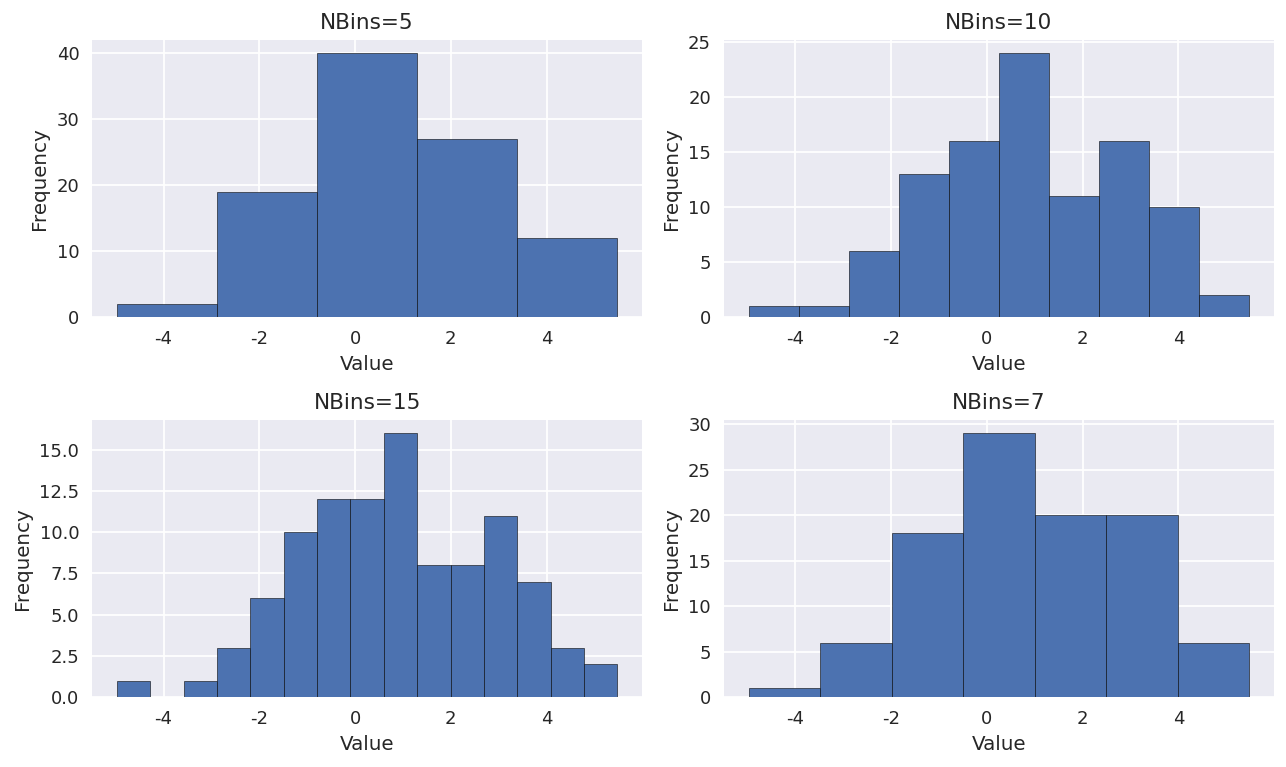

In [24]:
mpl.rcParams.update({
    "text.usetex": False,
    "axes.unicode_minus": False,
    "font.family": "DejaVu Sans",
    "figure.dpi": 130,
})

bins_list = [5, 10, 15, 7]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for ax, NBins in zip(axes.flatten(), bins_list):
    ax.hist(X, bins=NBins, edgecolor="black")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{NBins=}")
plt.tight_layout()  # оптимизирует отступы
plt.show()

In [25]:
def chi2_gof_normal(X, bins, m=None, std=None):
    n = len(X)
    r = 0
    if not m:
        m = X.mean()
        r += 1
    if not std:
        std = X.std(ddof=1)
        r += 1
    frequences, bin_edges = np.histogram(X, bins=bins)
    k = len(frequences)
    p_list = stats.norm.cdf(bin_edges[1:], loc=m, scale=std) - stats.norm.cdf(
        bin_edges[:-1], loc=m, scale=std
    )
    z = sum((frequences - n * p_list) ** 2 / (n * p_list))
    p_value = stats.chi2.sf(z, df=k - r - 1)
    return z, p_value

In [21]:
mprint(r"### $\chi^2$ goodness of fit test", f"$H_0: \\mathbf X \\sim N(?, ?)$")
for bins in bins_list:
    z, p_value = chi2_gof_normal(X, bins)
    mprint(
        f"#### NBins = {bins}",
        f"$z_{{выб}} =$ {z:.2f}",
        f"$p =$ {p_value:.2f}",
        verdict(alpha, p_value),
    )

### $\chi^2$ goodness of fit test

$H_0: \mathbf X \sim N(?, ?)$

#### NBins = 5

$z_{выб} =$ 1.79

$p =$ 0.41

...

$H_0$ принимается

#### NBins = 7

$z_{выб} =$ 3.54

$p =$ 0.47

$H_0$ принимается

In [26]:
def chi2_gof_uniform(X, bins, a=None, b=None):
    n = len(X)
    r = 0
    if not a:
        a = X.min()
        r += 1
    if not b:
        b = X.max()
        r += 1
    frequences, bin_edges = np.histogram(X, bins=bins)
    k = len(frequences)
    p_list = stats.uniform.cdf(bin_edges[1:], loc=a, scale=b - a) - stats.uniform.cdf(
        bin_edges[:-1], loc=a, scale=b - a
    )
    z = sum((frequences - n * p_list) ** 2 / (n * p_list))
    p_value = stats.chi2.sf(z, df=k - r - 1)
    return z, p_value

In [27]:
mprint(r"### $\chi^2$ goodness of fit test", f"$H_0: \\mathbf X \\sim R(?, ?)$")
for bins in bins_list:
    z, p_value = chi2_gof_uniform(X, bins)
    mprint(
        f"#### NBins = {bins}",
        f"$z_{{выб}} =$ {z:.2f}",
        f"$p =$ {p_value:.2f}",
        verdict(alpha, p_value),
    )

### $\chi^2$ goodness of fit test

$H_0: \mathbf X \sim R(?, ?)$

#### NBins = 5

$z_{выб} =$ 41.90

$p =$ 0.00

...

$H_0$ отклоняется

#### NBins = 7

$z_{выб} =$ 42.66

$p =$ 0.00

$H_0$ отклоняется

In [29]:
def chi2_gof_chi2(X, bins, df=None):
    n = len(X)
    r = 0
    if not df:
        df = stats.chi2.fit(X)[0]
        r += 1
    frequences, bin_edges = np.histogram(X, bins=bins)
    k = len(frequences)
    p_list = stats.chi2.cdf(bin_edges[1:], df=df) - stats.chi2.cdf(
        bin_edges[:-1], df=df
    )
    z = sum((frequences - n * p_list) ** 2 / (n * p_list))
    p_value = stats.chi2.sf(z, df=k - r - 1)
    return z, p_value

In [31]:
mprint(r"### $\chi^2$ goodness of fit test", f"$H_0: \\mathbf X \\sim \\chi^2(5)$")
for bins in bins_list:
    z, p_value = chi2_gof_chi2(X, bins, df=5)
    mprint(
        f"#### NBins = {bins}",
        f"$z_{{выб}} =$ {z:.2f}",
        f"$p =$ {p_value:.2f}",
        verdict(alpha, p_value),
    )

### $\chi^2$ goodness of fit test

$H_0: \mathbf X \sim \chi^2(5)$

/var/folders/d4/rpr57lh50cv40mlywst7vrgc0000gn/T/ipykernel_15388/3898661440.py:12: RuntimeWarning: divide by zero encountered in divide
  z = sum((frequences - n * p_list) ** 2 / (n * p_list))


#### NBins = 5

$z_{выб} =$ inf

...

$H_0$ принимается

#### NBins = 7

$z_{выб} =$ inf

$p =$ 0.00

$H_0$ отклоняется

In [32]:
mprint(r"### ks-test")

z, p_value = stats.kstest(X, stats.norm.cdf, args=(X.mean(), X.std(ddof=1)))
mprint(
    f"$H_0: \\mathbf X \\sim N(?, ?)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
    verdict(alpha, p_value),
)

z, p_value = stats.kstest(X, stats.uniform.cdf, args=(X.min(), X.max() - X.min()))
mprint(
    f"$H_0: \\mathbf X \\sim R(?, ?)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
    verdict(alpha, p_value),
)

z, p_value = stats.kstest(X, stats.chi2.cdf, args=(5,))
mprint(
    f"$H_0: \\mathbf X \\sim \\chi^2(5)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
    verdict(alpha, p_value),
)

### ks-test

$H_0: \mathbf X \sim N(?, ?)$

$z_{выб} =$ 0.05

$p =$ 0.93

$H_0$ принимается

...

$H_0$ отклоняется

$H_0: \mathbf X \sim \chi^2(5)$

$z_{выб} =$ 0.55

$p =$ 0.00

$H_0$ отклоняется

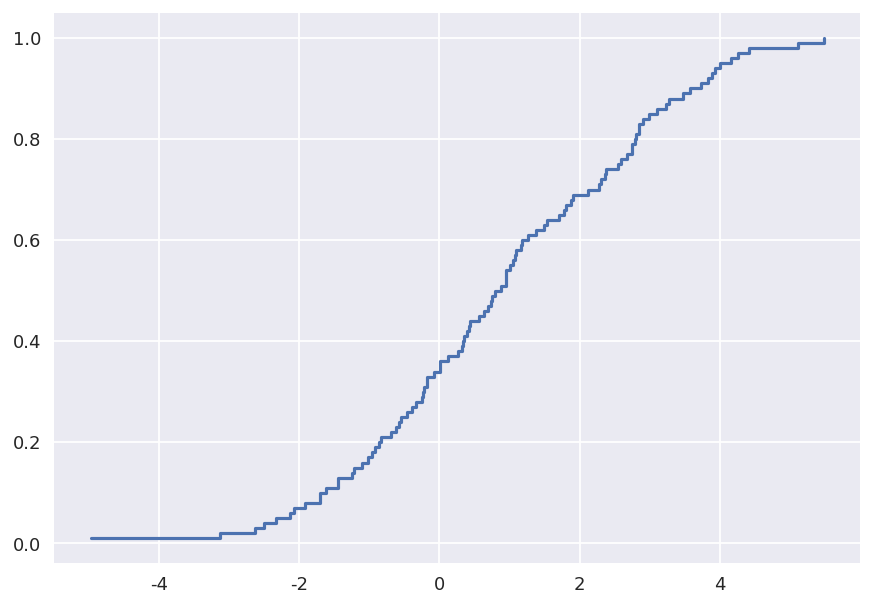

In [44]:
n = len(X)
X_sorted = np.sort(X)
F = np.arange(1, n + 1) / n

plt.step(X_sorted, F, where="post")
plt.show()

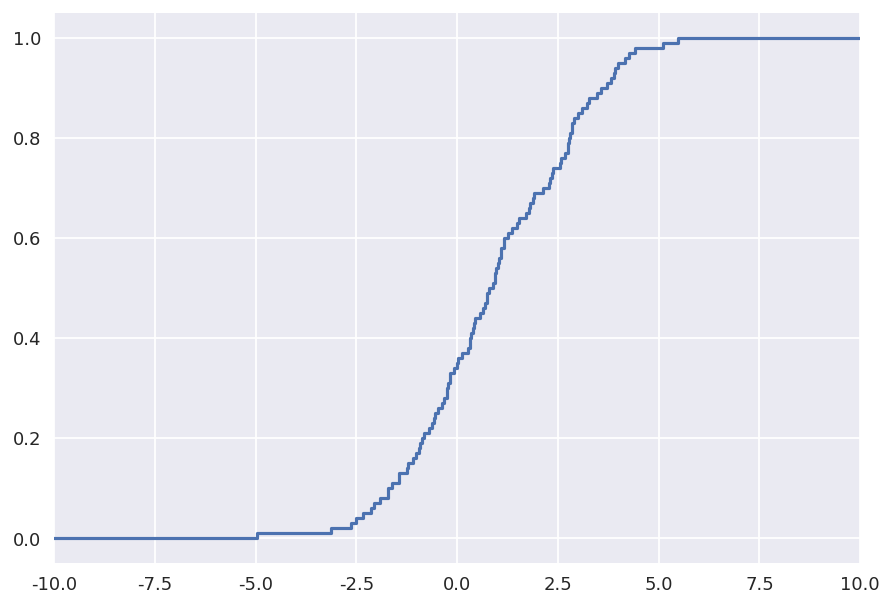

In [45]:
X_sorted = np.concatenate(([-10000], X_sorted, [10000]))
F = np.concatenate(([0], F, [1]))

plt.step(X_sorted, F, where="post")
plt.xlim(-10, 10)
plt.show()

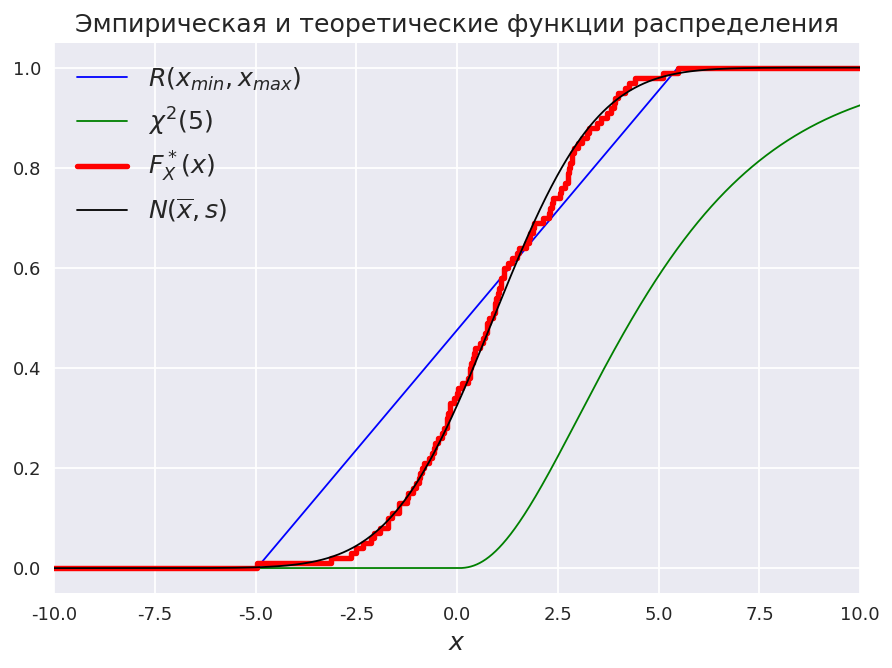

In [46]:
x = np.linspace(-11, 11, 10000)
norm = stats.norm.cdf(x, loc=X.mean(), scale=X.std(ddof=1))
uniform = stats.uniform.cdf(x, loc=X.min(), scale=X.max() - X.min())
chi2 = stats.chi2.cdf(x, df=5)

plt.plot(x, uniform, color="b", linewidth=1, label=r"$R(x_{min}, x_{max})$")
plt.plot(x, chi2, color="g", linewidth=1, label=r"$\chi^2(5)$")
plt.step(X_sorted, F, where="post", color="r", linewidth=3, label=r"$F^*_X(x)$")
plt.plot(x, norm, color="black", linewidth=1, label=r"$N(\overline {x}, s)$")

plt.title("Эмпирическая и теоретические функции распределения", fontsize=14)
plt.xlim(-10, 10)
plt.legend(fontsize=14)
plt.xlabel("$x$", fontsize=14)

plt.show()

In [47]:
Y = np.random.uniform(a2, b2, n2)

mprint(f"$\\mathbf{{Y}}$: {Y[:10].round(2)}")

$\mathbf{Y}$: [ 0.68 -0.76 -0.1  -0.74 -0.57  0.45 -0.93 -0.81  0.3  -0.51]

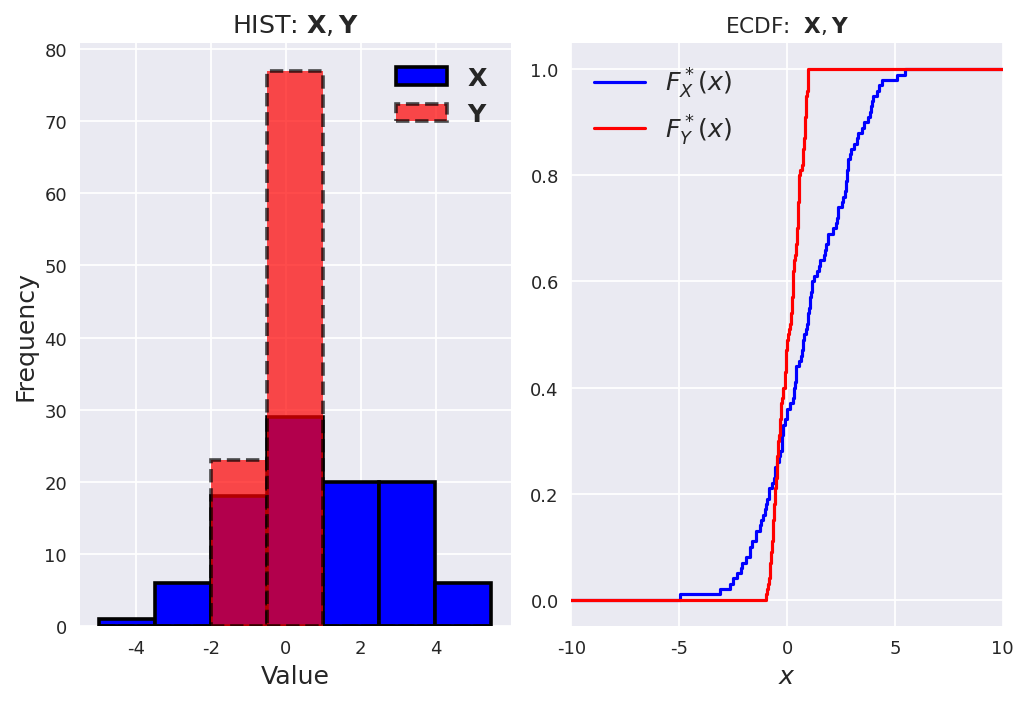

In [51]:
frequencesX, bin_edges = np.histogram(X, bins=7)
frequencesY, _ = np.histogram(Y, bin_edges)
plt.subplot(1, 2, 1)
plt.hist(
    X, bins=bin_edges, color="b", edgecolor="black", linewidth=2, label=r"$\mathbf{X}$"
)
plt.hist(
    Y,
    bins=bin_edges,
    color="r",
    edgecolor="black",
    alpha=0.7,
    linestyle="--",
    linewidth=2,
    label=r"$\mathbf{Y}$",
)
plt.legend(fontsize=14)
plt.xlabel("Value", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title(r"HIST: $\mathbf{X}, \mathbf{Y}$", fontsize=14)


n = len(X)
m = len(Y)

X_sorted = np.concatenate(([-10000], np.sort(X), [10000]))
F_x = np.concatenate(([0], np.arange(1, n + 1) / n, [1]))

Y_sorted = np.concatenate(([-10000], np.sort(Y), [10000]))
F_y = np.concatenate(([0], np.arange(1, m + 1) / m, [1]))

plt.subplot(1, 2, 2)
plt.step(X_sorted, F_x, where="post", color="b", label=r"$F_X^*(x)$")
plt.step(Y_sorted, F_y, where="post", color="r", label=r"$F_Y^*(x)$")
plt.legend(fontsize=14)
plt.xlabel(r"$x$", fontsize=14)
plt.title(r"ECDF:  $\mathbf{X}, \mathbf{Y}$")
plt.xlim(-10, 10)


plt.tight_layout()
plt.show()

In [52]:
def chi2_2samp(X, Y, bins):
    n = len(X)
    m = len(Y)
    frequencesX, bin_edges = np.histogram(
        X, bins=bins, range=(min(min(X), min(Y)), max(max(X), max(Y)))
    )
    frequencesY, bin_edges = np.histogram(Y, bins=bin_edges)
    z = (
        n
        * m
        * sum((frequencesX / n - frequencesY / m) ** 2 / (frequencesX + frequencesY))
    )
    p_value = stats.chi2.sf(z, df=8)
    return z, p_value

In [53]:
z, p_value = chi2_2samp(X, Y, bins=7)

mprint(
    r"### 2-sample $\chi^2$ test",
    f"$H_0: F_X(x) = F_Y(x)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
    verdict(alpha, p_value),
)

### 2-sample $\chi^2$ test

$H_0: F_X(x) = F_Y(x)$

$z_{выб} =$ 75.35

$p =$ 0.00

$H_0$ отклоняется

In [54]:
z, p_value = stats.ks_2samp(X, Y)

mprint(
    r"### 2-sample ks-test",
    f"$H_0: F_X(x) = F_Y(x)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
    verdict(alpha, p_value),
)

### 2-sample ks-test

$H_0: F_X(x) = F_Y(x)$

$z_{выб} =$ 0.46

$p =$ 0.00

$H_0$ отклоняется

In [55]:
z, p_value = sign_test(X - Y)
mprint(
    r"### Sign test",
    f"$H_0: F_X(x) = F_Y(x)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
    verdict(alpha, p_value),
)

### Sign test

$H_0: F_X(x) = F_Y(x)$

$z_{выб} =$ 14.00

$p =$ 0.01

$H_0$ отклоняется

In [56]:
z, p_value = stats.mannwhitneyu(X, Y)

mprint(
    r"### U-test",
    f"$H_0: F_X(x) = F_Y(x)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
    verdict(alpha, p_value),
)

### U-test

$H_0: F_X(x) = F_Y(x)$

$z_{выб} =$ 6475.00

$p =$ 0.00

$H_0$ отклоняется